<a href="https://colab.research.google.com/github/amyziyi97-prog/llm-visibility-improvement/blob/main/Data_Analysis_v4_add_t_test_for_gap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
# =========================
# Load experiment results
# =========================

coffee_files = [
    "coffee_results_batch_1.csv",
    "coffee_results_batch_2.csv",
    "coffee_results_batch_3.csv",
    "coffee_results_batch_4.csv"
]

vacuum_files = [
    "vacuum_results_batch_1.csv",
    "vacuum_results_batch_2.csv",
    "vacuum_results_batch_3.csv",
    "vacuum_results_batch_4.csv"
]

coffee_results_df = pd.concat(
    [pd.read_csv(f, encoding="latin1") for f in coffee_files],
    ignore_index=True
)

vacuum_results_df = pd.concat(
    [pd.read_csv(f, encoding="latin1") for f in vacuum_files],
    ignore_index=True
)

coffee_results_df["product_typology"] = "Experience Good"
vacuum_results_df["product_typology"] = "Search Good"

combined_results_df = pd.concat(
    [coffee_results_df, vacuum_results_df],
    ignore_index=True
)

BASELINE_NAME = "1_Baseline"

display(combined_results_df.head())
print(combined_results_df.shape)

,product_category,product_typology,batch_id,condition,iteration,raw_response,brand,brand_role,is_leader,is_challenger,rank,rrs,prominence_score,word_count,mentioned_text,trust_score,purchase_intent_score,persona_scores
0,Coffee Beans,Experience Good,1,1_Baseline,1,"Based on the provided search results, here are...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.180,51,1. Ethiopia Yirgacheffe Reserve - This is the ...,NaN,NaN,NaN
1,Coffee Beans,Experience Good,1,1_Baseline,1,"Based on the provided search results, here are...",NovaBean Heritage,Challenger,0,1,4,0.25,0.095,37,"4. NovaBean Heritage - A reliable, all-purpose...",4.0,3.3,"{'budget_buyer': {'trust_score': 4, 'purchase_..."
2,Coffee Beans,Experience Good,1,1_Baseline,2,"Based solely on the provided search results, h...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.300,54,"Ethiopia Yirgacheffe Reserve ($28.00, Rating: ...",NaN,NaN,NaN
3,Coffee Beans,Experience Good,1,1_Baseline,2,"Based solely on the provided search results, h...",NovaBean Heritage,Challenger,0,1,0,0.00,0.000,0,NaN,NaN,NaN,{}
4,Coffee Beans,Experience Good,1,1_Baseline,3,"Based solely on the provided search results, h...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.185,39,1. Ethiopia Yirgacheffe Reserve â?This is the...,NaN,NaN,NaN


(3200, 18)


# 2. Core Analysis Functions



In [4]:
# ANALYTICAL METRICS
# ============================================================
# A. Relative Percentage Gain
# Only for challenger
# ΔMetric = (Metric_condition - Metric_baseline) / Metric_baseline
# ----------------------------------------------------------
def compute_relative_gain(df, dv_col, baseline_name=BASELINE_NAME):
    df_ch = df[df["is_challenger"] == 1].copy()

    baseline_df = (
        df_ch[df_ch["condition"] == baseline_name]
        [["product_typology", "iteration", "brand", dv_col]]
        .rename(columns={dv_col: f"{dv_col}_baseline"})
    )

    merged = df_ch.merge(
        baseline_df,
        on=["product_typology", "iteration", "brand"],
        how="left"
    )

    merged["relative_gain"] = np.where(
        merged[f"{dv_col}_baseline"].fillna(0) == 0,
        np.nan,
        (merged[dv_col] - merged[f"{dv_col}_baseline"]) / merged[f"{dv_col}_baseline"]
    )

    return merged

# ------------------------------------------------------------
# B. Visibility Gap
# Gap = Leader - Challenger
# ------------------------------------------------------------
def compute_visibility_gap(df, dv_col):
    gap_rows = []

    for (typology, condition, iteration), g in df.groupby(
        ["product_typology", "condition", "iteration"]
    ):
        leader_val = g[g["is_leader"] == 1][dv_col].mean()
        challenger_val = g[g["is_challenger"] == 1][dv_col].mean()

        gap_rows.append({
            "product_typology": typology,
            "condition": condition,
            "iteration": iteration,
            "leader_value": leader_val,
            "challenger_value": challenger_val,
            "gap": leader_val - challenger_val
        })

    return pd.DataFrame(gap_rows)

# ------------------------------------------------------------
# C. Gap Reduction
# Gap Reduction = Gap_baseline - Gap_strategy
# positive = Challenger narrows the gap
# ------------------------------------------------------------
def compute_gap_reduction(gap_df, baseline_name=BASELINE_NAME):
    baseline_gap = (
        gap_df[gap_df["condition"] == baseline_name]
        [["product_typology", "iteration", "gap"]]
        .rename(columns={"gap": "gap_baseline"})
    )
    merged = gap_df.merge(baseline_gap, on=["product_typology", "iteration"], how="left")
    merged["gap_reduction"] = merged["gap_baseline"] - merged["gap"]

    return merged

# ------------------------------------------------------------
# D. Paired t-test
# Challenger only, within each product typology.
# ------------------------------------------------------------
def run_ttest_against_baseline(df, dv_col, baseline_name=BASELINE_NAME):
    output = []

    df_ch = df[df["is_challenger"] == 1].copy()

    baseline = (
        df_ch[df_ch["condition"] == baseline_name]
        [["product_typology", "iteration", "brand", dv_col]]
        .rename(columns={dv_col: "baseline_dv"})
    )

    for (typology, strategy), current in df_ch.groupby(["product_typology", "condition"]):
        if strategy == baseline_name:
            continue

        merged = current[["product_typology", "iteration", "brand", dv_col]].merge(
            baseline,
            on=["product_typology", "iteration", "brand"],
            how="inner"
        )

        merged_clean = merged.dropna(subset=[dv_col, "baseline_dv"])

        if len(merged_clean) < 2:
            stat, p_value = np.nan, np.nan
        else:
            stat, p_value = ttest_rel(
                merged_clean[dv_col],
                merged_clean["baseline_dv"]
            )

        output.append({
            "product_typology": typology,
            "dv": dv_col,
            "strategy": strategy,
            "n_pairs": len(merged_clean),
            "t_stat": stat,
            "p_value": p_value,
            "mean_strategy": merged_clean[dv_col].mean(),
            "mean_baseline": merged_clean["baseline_dv"].mean()
        })

    return pd.DataFrame(output)

# 3. Run Analysis

In [5]:
dv_cols = [
    "rrs",
    "prominence_score",
    "trust_score",
    "purchase_intent_score"
]

gain_dfs = {
    dv: compute_relative_gain(combined_results_df, dv_col=dv)
    for dv in dv_cols
}

gap_rrs_df = compute_visibility_gap(combined_results_df, dv_col="rrs")
gap_imp_df = compute_visibility_gap(combined_results_df, dv_col="prominence_score")

gap_reduction_rrs_df = compute_gap_reduction(gap_rrs_df)
gap_reduction_imp_df = compute_gap_reduction(gap_imp_df)

ttest_df = pd.concat(
    [run_ttest_against_baseline(combined_results_df, dv_col=dv) for dv in dv_cols],
    ignore_index=True
)


# 4. Final Tables

In [6]:
# ===============================
# Table 1: Descriptive Statistics
# ===============================

metrics = [
    "rrs",
    "prominence_score",
    "word_count",
    "trust_score",
    "purchase_intent_score"
]

metric_labels = {
    "rrs": "RRS",
    "prominence_score": "Prominence",
    "word_count": "Word Count",
    "trust_score": "Trust",
    "purchase_intent_score": "Purchase Intent"
}
stat_labels = {
    "mean": "Mean",
    "std": "SD",
    "min": "Min",
    "max": "Max"
}

def make_desc_table_by_role(data, typology):
    sub = data[data["product_typology"] == typology].copy()

    table = (
        sub.groupby(["condition", "brand_role"])[metrics]
        .agg(["mean", "std", "min", "max"])
        .round(3)
    )

    # Rename metric level
    table = table.rename(columns=metric_labels, level=0)

    # Rename statistic level
    table = table.rename(columns=stat_labels, level=1)

    return table
combined_results_df

# Create two separate tables
table_search = make_desc_table_by_role(combined_results_df, "Search Good")
table_experience = make_desc_table_by_role(combined_results_df, "Experience Good")

display(table_search)
display(table_experience)

RRS                      Prominence  \
                                     Mean     SD    Min    Max       Mean   
condition               brand_role                                          
1_Baseline              Challenger  0.214  0.035  0.143  0.250      0.092   
                        Leader      0.980  0.098  0.500  1.000      0.172   
2_Keyword_Stuffing      Challenger  0.206  0.034  0.143  0.250      0.096   
                        Leader      0.990  0.070  0.500  1.000      0.174   
3_Statistics_Addition   Challenger  0.251  0.031  0.167  0.333      0.111   
                        Leader      0.970  0.119  0.500  1.000      0.172   
4_Citation_Injection    Challenger  0.239  0.027  0.167  0.333      0.109   
                        Leader      0.965  0.128  0.500  1.000      0.177   
5_Fluency_Optimization  Challenger  0.218  0.034  0.143  0.333      0.094   
                        Leader      0.990  0.070  0.500  1.000      0.178   
6_Easy_to_Understand    Challenger  0.202  0.039  0.125  0.333      0.095   
                        Leader      0.975  0.110  0.500  1.000      0.173   
7_Authoritative_Tone    Challenger  0.248  0.030  0.167  0.333      0.105   
                        Leader      0.985  0.086  0.500  1.000      0.176   
8_Comparative_Synthesis Challenger  0.222  0.039  0.143  0.333      0.098   
                        Leader      0.955  0.144  0.500  1.000      0.173   

                                                        Word Count             \
                                       SD    Min    Max       Mean     SD Min   
condition               brand_role                                              
1_Baseline              Challenger  0.014  0.060  0.129      37.01  4.511  27   
                        Leader      0.019  0.136  0.262      47.01  4.282  37   
2_Keyword_Stuffing      Challenger  0.013  0.068  0.145      39.16  5.075  28   
                        Leader      0.016  0.133  0.264      47.63  5.293  35   
3_Statistics_Addition   Challenger  0.012  0.085  0.166      41.65  6.083  32   
                        Leader      0.020  0.127  0.262      47.06  5.473  35   
4_Citation_Injection    Challenger  0.012  0.081  0.151      40.31  4.256  31   
                        Leader      0.021  0.130  0.241      46.60  4.559  37   
5_Fluency_Optimization  Challenger  0.016  0.000  0.138      35.95  5.700   0   
                        Leader      0.021  0.141  0.274      46.58  4.546  34   
6_Easy_to_Understand    Challenger  0.017  0.000  0.137      39.13  6.033   0   
                        Leader      0.019  0.133  0.251      46.95  5.338  36   
7_Authoritative_Tone    Challenger  0.016  0.000  0.141      38.54  6.101   0   
                        Leader      0.022  0.141  0.302      46.92  4.514  36   
8_Comparative_Synthesis Challenger  0.013  0.064  0.131      38.25  4.926  28   
                        Leader      0.020  0.132  0.228      46.57  4.827  33   

                                        Trust                   \
                                   Max   Mean     SD  Min  Max   
condition               brand_role                               
1_Baseline              Challenger  48  4.194  0.405  3.0  5.0   
                        Leader      59    NaN    NaN  NaN  NaN   
2_Keyword_Stuffing      Challenger  50  4.738  0.272  4.0  5.3   
                        Leader      62    NaN    NaN  NaN  NaN   
3_Statistics_Addition   Challenger  82  4.559  0.397  4.0  5.3   
                        Leader      67    NaN    NaN  NaN  NaN   
4_Citation_Injection    Challenger  50  4.355  0.362  3.7  5.0   
                        Leader      61    NaN    NaN  NaN  NaN   
5_Fluency_Optimization  Challenger  48  4.211  0.474  3.0  5.0   
                        Leader      58    NaN    NaN  NaN  NaN   
6_Easy_to_Understand    Challenger  55  4.164  0.548  3.0  5.7   
                        Leader      62    NaN    NaN  NaN  NaN   
7_Authoritative_Tone    Challenger  53  3.83

RRS                     Prominence  \
                                     Mean     SD    Min   Max       Mean   
condition               brand_role                                         
1_Baseline              Challenger  0.203  0.043  0.000  0.25      0.094   
                        Leader      1.000  0.000  1.000  1.00      0.182   
2_Keyword_Stuffing      Challenger  0.201  0.038  0.125  0.25      0.092   
                        Leader      1.000  0.000  1.000  1.00      0.179   
3_Statistics_Addition   Challenger  0.213  0.034  0.167  0.25      0.105   
                        Leader      1.000  0.000  1.000  1.00      0.175   
4_Citation_Injection    Challenger  0.210  0.034  0.125  0.25      0.098   
                        Leader      1.000  0.000  1.000  1.00      0.181   
5_Fluency_Optimization  Challenger  0.206  0.037  0.125  0.25      0.097   
                        Leader      1.000  0.000  1.000  1.00      0.184   
6_Easy_to_Understand    Challenger  0.212  0.035  0.167  0.25      0.101   
                        Leader      1.000  0.000  1.000  1.00      0.180   
7_Authoritative_Tone    Challenger  0.220  0.035  0.143  0.25      0.101   
                        Leader      1.000  0.000  1.000  1.00      0.178   
8_Comparative_Synthesis Challenger  0.222  0.035  0.125  0.25      0.101   
                        Leader      1.000  0.000  1.000  1.00      0.179   

                                                        Word Count             \
                                       SD    Min    Max       Mean     SD Min   
condition               brand_role                                              
1_Baseline              Challenger  0.016  0.000  0.141      41.30  6.903   0   
                        Leader      0.026  0.147  0.300      52.28  6.299  38   
2_Keyword_Stuffing      Challenger  0.014  0.064  0.128      42.48  5.580  28   
                        Leader      0.020  0.146  0.265      53.93  6.092  39   
3_Statistics_Addition   Challenger  0.015  0.081  0.174      46.81  5.999  32   
                        Leader      0.018  0.147  0.251      53.26  5.867  37   
4_Citation_Injection    Challenger  0.012  0.069  0.141      43.32  5.689  30   
                        Leader      0.022  0.149  0.291      53.39  6.985  39   
5_Fluency_Optimization  Challenger  0.016  0.063  0.163      43.04  4.942  32   
                        Leader      0.023  0.151  0.269      53.52  5.991  40   
6_Easy_to_Understand    Challenger  0.015  0.073  0.147      44.55  5.593  33   
                        Leader      0.023  0.139  0.268      53.29  7.348  37   
7_Authoritative_Tone    Challenger  0.012  0.077  0.123      45.17  4.987  34   
                        Leader      0.017  0.137  0.263      54.37  6.073  42   
8_Comparative_Synthesis Challenger  0.014  0.068  0.151      44.10  5.283  34   
                        Leader      0.020  0.148  0.276      53.75  5.844  41   

                                        Trust                   \
                                   Max   Mean     SD  Min  Max   
condition               brand_role                               
1_Baseline              Challenger  62  4.147  0.307  4.0  5.7   
                        Leader      72    NaN    NaN  NaN  NaN   
2_Keyword_Stuffing      Challenger  55  4.128  0.288  3.3  5.0   
                        Leader      68    NaN    NaN  NaN  NaN   
3_Statistics_Addition   Challenger  66  4.547  0.337  4.0  5.3   
                        Leader      71    NaN    NaN  NaN  NaN   
4_Citation_Injection    Challenger  58  4.320  0.367  3.7  5.0   
                        Leader      73    NaN    NaN  NaN  NaN   
5_Fluency_Optimization  Challenger  63  4.082  0.321  3.3  5.0   
                        Leader      67    NaN    NaN  NaN  NaN   
6_Easy_to_Understand    Challenger  60  4.137  0.281  4.0  5.0   
                        Leader      71    NaN    NaN  NaN  NaN   
7_Authoritative_Tone    Challenger  60  3.856  0.421  3.0  5.0 

In [7]:
experience_latex = table_experience.to_latex(
    caption="Descriptive Statistics for Experience Goods by Brand Role",
    label="tab:desc_experience_role",
    multicolumn=True,
    multirow=True,
    bold_rows=True,
    float_format="%.2f",
    na_rep="\-",
    escape=False
)

search_latex = table_search.to_latex(
    caption="Descriptive Statistics for Search Goods by Brand Role",
    label="tab:desc_search_role",
    multicolumn=True,
    multirow=True,
    bold_rows=True,
    float_format="%.2f",
    na_rep="\-",
    escape=False
)

print(search_latex)
print(experience_latex)

with open("table_desc_search_role.tex", "w", encoding="utf-8") as f:
    f.write(search_latex)

with open("table_desc_experience_role.tex", "w", encoding="utf-8") as f:
    f.write(experience_latex)

<>:8: SyntaxWarning: invalid escape sequence '\-'
<>:19: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\-'
<>:19: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_5282/3479270261.py:8: SyntaxWarning: invalid escape sequence '\-'
  na_rep="\-",
/tmp/ipykernel_5282/3479270261.py:19: SyntaxWarning: invalid escape sequence '\-'
  na_rep="\-",


\begin{table}
\caption{Descriptive Statistics for Search Goods by Brand Role}
\label{tab:desc_search_role}
\begin{tabular}{llrrrrrrrrrrrrrrrrrrrr}
\toprule
 &  & \multicolumn{4}{r}{RRS} & \multicolumn{4}{r}{Prominence} & \multicolumn{4}{r}{Word Count} & \multicolumn{4}{r}{Trust} & \multicolumn{4}{r}{Purchase Intent} \\
 &  & Mean & SD & Min & Max & Mean & SD & Min & Max & Mean & SD & Min & Max & Mean & SD & Min & Max & Mean & SD & Min & Max \\
condition & brand_role &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{\textbf{1_Baseline}} & \textbf{Challenger} & 0.21 & 0.04 & 0.14 & 0.25 & 0.09 & 0.01 & 0.06 & 0.13 & 37.01 & 4.51 & 27 & 48 & 4.19 & 0.41 & 3.00 & 5.00 & 3.46 & 0.61 & 2.30 & 5.00 \\
\textbf{} & \textbf{Leader} & 0.98 & 0.10 & 0.50 & 1.00 & 0.17 & 0.02 & 0.14 & 0.26 & 47.01 & 4.28 & 37 & 59 & \- & \- & \- & \- & \- & \- & \- & \- \\
\cline{1-22}
\multirow[t]{2}{*}{\textbf{2_Keyword_Stuffing}} & \textbf{Challenger} & 0.21 & 0.03 & 0.14

In [8]:
# ===============================
# Table 2: Relative Percentage Gain
# Challenger only
# ΔMetric = (Metric_condition - Metric_baseline) / Metric_baseline × 100
# ===============================
table_relative_gain = None
dv_label_map = {
    "rrs": "Δ RRS (%)",
    "prominence_score": "Δ Prominence (%)",
    "trust_score": "Δ Trust (%)",
    "purchase_intent_score": "Δ Purchase Intent (%)"
}
for dv, df_gain in gain_dfs.items():
    tmp = (
        df_gain
        .query("condition != @BASELINE_NAME")
        .groupby(["product_typology", "condition"])
        .agg(**{dv_label_map[dv]: ("relative_gain", lambda x: x.mean() * 100)})
        .reset_index()
    )

    if table_relative_gain is None:
        table_relative_gain = tmp
    else:
        table_relative_gain = table_relative_gain.merge(
            tmp,
            on=["product_typology", "condition"],
            how="outer"
        )

# Split into two formal tables
table2_experience = (
    table_relative_gain
    .query("product_typology == 'Experience Good'")
    .drop(columns="product_typology")
    .set_index("condition")
    .round(3)
)

table2_search = (
    table_relative_gain
    .query("product_typology == 'Search Good'")
    .drop(columns="product_typology")
    .set_index("condition")
    .round(3)
)
table2_experience = table2_experience.sort_values(by="Δ RRS (%)", ascending=False)
table2_search = table2_search.sort_values(by="Δ RRS (%)", ascending=False)
display(table2_experience)
display(table2_search)
table_relative_gain = None

,Δ RRS (%),Δ Prominence (%),Δ Trust (%),Δ Purchase Intent (%)
condition,,,,
8_Comparative_Synthesis,11.366,9.066,-2.599,8.790
7_Authoritative_Tone,11.259,9.320,-6.508,6.017
3_Statistics_Addition,7.055,12.534,10.061,16.172
6_Easy_to_Understand,6.154,8.977,0.263,7.328
4_Citation_Injection,5.134,5.268,4.684,6.902
5_Fluency_Optimization,3.191,4.364,-1.386,3.985
2_Keyword_Stuffing,0.977,-0.705,-0.128,4.432


,Δ RRS (%),Δ Prominence (%),Δ Trust (%),Δ Purchase Intent (%)
condition,,,,
3_Statistics_Addition,21.039,23.834,9.659,21.295
7_Authoritative_Tone,19.396,16.073,-7.587,-2.648
4_Citation_Injection,15.069,21.475,4.738,9.103
8_Comparative_Synthesis,6.674,9.051,-2.593,1.505
5_Fluency_Optimization,4.785,4.866,1.209,5.551
2_Keyword_Stuffing,-0.606,6.483,14.008,34.083
6_Easy_to_Understand,-2.696,5.617,0.120,0.693


In [9]:
# ============================================================
# Table 2: Relative Percentage Gain - Panel LaTeX Export
# ============================================================

def to_panel_latex_relative_gain(table_exp, table_search):

    def extract_body(df):
        latex = df.to_latex(
            index=True,
            float_format="%.3f",
            na_rep="\\textemdash",
            escape=False
        )

        lines = latex.splitlines()
        start = [i for i, l in enumerate(lines) if "\\toprule" in l][0]
        end = [i for i, l in enumerate(lines) if "\\bottomrule" in l][0]

        return lines[start:end + 1]

    body_exp = extract_body(table_exp)
    body_search = extract_body(table_search)

    # +1 because index column "condition" is included
    n_cols = len(table_exp.columns) + 1

    latex = []
    latex.append("\\begin{table}[htbp]")
    latex.append("\\centering")
    latex.append("\\caption{Relative Percentage Gain by Product Typology}")
    latex.append("\\label{tab:relative-gain-panels}")
    latex.append("\\resizebox{\\textwidth}{!}{%")
    latex.append(f"\\begin{{tabular}}{{{'l' + 'c' * (n_cols - 1)}}}")

    # Panel A
    latex.append(
        f"\\multicolumn{{{n_cols}}}{{l}}{{\\textbf{{Panel A: Coffee Beans (Experience Goods)}}}} \\\\"
    )
    latex.extend(body_exp)

    latex.append("\\\\[1em]")

    # Panel B
    latex.append(
        f"\\multicolumn{{{n_cols}}}{{l}}{{\\textbf{{Panel B: Robot Vacuums (Search Goods)}}}} \\\\"
    )
    latex.extend(body_search)

    latex.append("\\end{tabular}%")
    latex.append("}")
    latex.append("\\end{table}")

    return "\n".join(latex)


# Generate panel LaTeX
relative_gain_panel_latex = to_panel_latex_relative_gain(
    table2_experience,
    table2_search
)

print(relative_gain_panel_latex)

with open("table2_relative_gain_panel.tex", "w", encoding="utf-8") as f:
    f.write(relative_gain_panel_latex)

\begin{table}[htbp]
\centering
\caption{Relative Percentage Gain by Product Typology}
\label{tab:relative-gain-panels}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\multicolumn{5}{l}{\textbf{Panel A: Coffee Beans (Experience Goods)}} \\
\toprule
 & Δ RRS (%) & Δ Prominence (%) & Δ Trust (%) & Δ Purchase Intent (%) \\
condition &  &  &  &  \\
\midrule
8_Comparative_Synthesis & 11.366 & 9.066 & -2.599 & 8.790 \\
7_Authoritative_Tone & 11.259 & 9.320 & -6.508 & 6.017 \\
3_Statistics_Addition & 7.055 & 12.534 & 10.061 & 16.172 \\
6_Easy_to_Understand & 6.154 & 8.977 & 0.263 & 7.328 \\
4_Citation_Injection & 5.134 & 5.268 & 4.684 & 6.902 \\
5_Fluency_Optimization & 3.191 & 4.364 & -1.386 & 3.985 \\
2_Keyword_Stuffing & 0.977 & -0.705 & -0.128 & 4.432 \\
\bottomrule
\\[1em]
\multicolumn{5}{l}{\textbf{Panel B: Robot Vacuums (Search Goods)}} \\
\toprule
 & Δ RRS (%) & Δ Prominence (%) & Δ Trust (%) & Δ Purchase Intent (%) \\
condition &  &  &  &  \\
\midrule
3_Statistics_Addition & 21.03

In [22]:
# Table 3: Paired t-test Results
def prepare_ttest_table(ttest_df):

    df = ttest_df.copy()

    df = df[df["strategy"] != BASELINE_NAME]

    df = df.rename(columns={
        "strategy": "Condition",
        "dv": "DV",
        "mean_baseline": "Mean Baseline",
        "mean_strategy": "Mean Strategy",
        "n_pairs": "N",
        "p_value": "p-value",
        "t_stat": "t-stat"
    })

    # Difference
    df["Difference"] = df["Mean Strategy"] - df["Mean Baseline"]

    # Significance stars
    def significance(p):
        if pd.isna(p):
            return ""
        elif p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    df["Sig."] = df["p-value"].apply(significance)

    df["p-value"] = df.apply(
        lambda row: f"{row['p-value']:.3f}{row['Sig.']}" if pd.notna(row["p-value"]) else "",
        axis=1
    )

    # Round
    df = df.round({
        "Mean Baseline": 3,
        "Mean Strategy": 3,
        "Difference": 3,
        "t-stat": 3
    })

    df = df[[
        "product_typology",
        "Condition",
        "DV",
        "Mean Baseline",
        "Mean Strategy",
        "Difference",
        "t-stat",
        "p-value"
    ]]

    return df

table3 = prepare_ttest_table(ttest_df)
table3_experience = (
    table3[table3["product_typology"] == "Experience Good"]
    .drop(columns="product_typology")
)

table3_search = (
    table3[table3["product_typology"] == "Search Good"]
    .drop(columns="product_typology")
)

display(table3_experience)
display(table3_search)

,Condition,DV,Mean Baseline,Mean Strategy,Difference,t-stat,p-value
0,2_Keyword_Stuffing,rrs,0.203,0.201,-0.002,-0.410,0.683
1,3_Statistics_Addition,rrs,0.203,0.213,0.009,1.608,0.111
2,4_Citation_Injection,rrs,0.203,0.210,0.006,1.135,0.259
3,5_Fluency_Optimization,rrs,0.203,0.206,0.003,0.495,0.622
4,6_Easy_to_Understand,rrs,0.203,0.212,0.008,1.694,0.093
5,7_Authoritative_Tone,rrs,0.203,0.220,0.016,2.850,0.005**
6,8_Comparative_Synthesis,rrs,0.203,0.222,0.019,3.515,0.001***
14,2_Keyword_Stuffing,prominence_score,0.094,0.092,-0.001,-0.561,0.576
15,3_Statistics_Addition,prominence_score,0.094,0.105,0.011,4.767,0.000***
16,4_Citation_Injection,prominence_score,0.094,0.098,0.004,1.867,0.065


,Condition,DV,Mean Baseline,Mean Strategy,Difference,t-stat,p-value
7,2_Keyword_Stuffing,rrs,0.214,0.206,-0.008,-1.521,0.132
8,3_Statistics_Addition,rrs,0.214,0.251,0.037,7.912,0.000***
9,4_Citation_Injection,rrs,0.214,0.238,0.025,5.379,0.000***
10,5_Fluency_Optimization,rrs,0.214,0.218,0.005,1.005,0.317
11,6_Easy_to_Understand,rrs,0.214,0.202,-0.011,-2.204,0.030*
12,7_Authoritative_Tone,rrs,0.214,0.248,0.035,7.964,0.000***
13,8_Comparative_Synthesis,rrs,0.214,0.222,0.008,1.589,0.115
21,2_Keyword_Stuffing,prominence_score,0.092,0.096,0.004,1.799,0.075
22,3_Statistics_Addition,prominence_score,0.092,0.111,0.019,10.346,0.000***
23,4_Citation_Injection,prominence_score,0.092,0.109,0.017,9.069,0.000***


In [23]:
latex_exp = table3_experience.to_latex(
    caption="Paired t-test Results for Experience Goods",
    label="tab:ttest-experience",
    index=False,
    bold_rows=False,
    float_format="%.3f",
    na_rep="\\textemdash",
    escape=False
)

latex_search = table3_search.to_latex(
    caption="Paired t-test Results for Search Goods",
    label="tab:ttest-search",
    index=False,
    bold_rows=False,
    float_format="%.3f",
    na_rep="\\textemdash",
    escape=False
)
print(latex_exp)
print(latex_search)

\begin{table}
\caption{Paired t-test Results for Experience Goods}
\label{tab:ttest-experience}
\begin{tabular}{llrrrrl}
\toprule
Condition & DV & Mean Baseline & Mean Strategy & Difference & t-stat & p-value \\
\midrule
2_Keyword_Stuffing & rrs & 0.203 & 0.201 & -0.002 & -0.410 & 0.683 \\
3_Statistics_Addition & rrs & 0.203 & 0.213 & 0.009 & 1.608 & 0.111 \\
4_Citation_Injection & rrs & 0.203 & 0.210 & 0.006 & 1.135 & 0.259 \\
5_Fluency_Optimization & rrs & 0.203 & 0.206 & 0.003 & 0.495 & 0.622 \\
6_Easy_to_Understand & rrs & 0.203 & 0.212 & 0.008 & 1.694 & 0.093 \\
7_Authoritative_Tone & rrs & 0.203 & 0.220 & 0.016 & 2.850 & 0.005** \\
8_Comparative_Synthesis & rrs & 0.203 & 0.222 & 0.019 & 3.515 & 0.001*** \\
2_Keyword_Stuffing & prominence_score & 0.094 & 0.092 & -0.001 & -0.561 & 0.576 \\
3_Statistics_Addition & prominence_score & 0.094 & 0.105 & 0.011 & 4.767 & 0.000*** \\
4_Citation_Injection & prominence_score & 0.094 & 0.098 & 0.004 & 1.867 & 0.065 \\
5_Fluency_Optimization & 

In [12]:
# Table 4: Visibility Gap
table_gap_rrs = (
    gap_rrs_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_rrs=("gap", "mean"))
    .reset_index()
)

table_gap_imp = (
    gap_imp_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_imp_pwc=("gap", "mean"))
    .reset_index()
)

table_gap = table_gap_rrs.merge(
    table_gap_imp,
    on=["product_typology", "condition"],
    how="outer"
)

display(table_gap)

,product_typology,condition,mean_gap_rrs,mean_gap_imp_pwc
0,Experience Good,1_Baseline,0.79661,0.08815
1,Experience Good,2_Keyword_Stuffing,0.79889,0.08704
2,Experience Good,3_Statistics_Addition,0.78742,0.07093
3,Experience Good,4_Citation_Injection,0.79041,0.08299
4,Experience Good,5_Fluency_Optimization,0.79406,0.08675
5,Experience Good,6_Easy_to_Understand,0.78841,0.07839
6,Experience Good,7_Authoritative_Tone,0.78050,0.07673
7,Experience Good,8_Comparative_Synthesis,0.77778,0.07818
8,Search Good,1_Baseline,0.76631,0.07986
9,Search Good,2_Keyword_Stuffing,0.78395,0.07798


In [13]:
# Table 5: Gap Reduction
table_gap_reduction_rrs = (
    gap_reduction_rrs_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
)

table_gap_reduction_imp = (
    gap_reduction_imp_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_imp_pwc=("gap_reduction", "mean"))
    .reset_index()
)

table_gap_reduction = table_gap_reduction_rrs.merge(
    table_gap_reduction_imp,
    on=["product_typology", "condition"],
    how="outer"
)

display(table_gap_reduction)

,product_typology,condition,mean_gap_reduction_rrs,mean_gap_reduction_imp_pwc
0,Experience Good,1_Baseline,0.00000,0.00000
1,Experience Good,2_Keyword_Stuffing,-0.00228,0.00111
2,Experience Good,3_Statistics_Addition,0.00919,0.01722
3,Experience Good,4_Citation_Injection,0.00620,0.00516
4,Experience Good,5_Fluency_Optimization,0.00255,0.00140
5,Experience Good,6_Easy_to_Understand,0.00820,0.00976
6,Experience Good,7_Authoritative_Tone,0.01611,0.01142
7,Experience Good,8_Comparative_Synthesis,0.01883,0.00997
8,Search Good,1_Baseline,0.00000,0.00000
9,Search Good,2_Keyword_Stuffing,-0.01764,0.00188


In [14]:
# ============================================================
# Gap Reduction t-test against 0
# H0: mean gap reduction = 0
# Positive mean = challenger narrows the gap
# ============================================================
def run_gap_reduction_ttest(gap_reduction_df, dv_name, baseline_name=BASELINE_NAME):
    output = []

    test_df = gap_reduction_df.query("condition != @baseline_name").copy()

    for (typology, condition), g in test_df.groupby(["product_typology", "condition"]):
        values = g["gap_reduction"].dropna()

        if len(values) < 2:
            t_stat, p_value = np.nan, np.nan
        else:
            t_stat, p_value = ttest_1samp(values, popmean=0)

        output.append({
            "product_typology": typology,
            "condition": condition,
            "dv": dv_name,
            "mean_gap_reduction": values.mean(),
            "sd_gap_reduction": values.std(),
            "n": len(values),
            "t_stat": t_stat,
            "p_value": p_value
        })

    return pd.DataFrame(output)

gap_reduction_ttest_df = pd.concat([
run_gap_reduction_ttest(gap_reduction_rrs_df, "RRS"),
run_gap_reduction_ttest(gap_reduction_imp_df, "Prominence")
], ignore_index=True)

display(gap_reduction_ttest_df)

,product_typology,condition,dv,mean_gap_reduction,sd_gap_reduction,n,t_stat,p_value
0,Experience Good,2_Keyword_Stuffing,RRS,-0.00228,0.055652,100,-0.409688,6.829198e-01
1,Experience Good,3_Statistics_Addition,RRS,0.00919,0.057165,100,1.607628,1.111014e-01
2,Experience Good,4_Citation_Injection,RRS,0.00620,0.054631,100,1.134879,2.591662e-01
3,Experience Good,5_Fluency_Optimization,RRS,0.00255,0.051511,100,0.495044,6.216661e-01
4,Experience Good,6_Easy_to_Understand,RRS,0.00820,0.048409,100,1.693906,9.342716e-02
5,Experience Good,7_Authoritative_Tone,RRS,0.01611,0.056531,100,2.849745,5.323697e-03
6,Experience Good,8_Comparative_Synthesis,RRS,0.01883,0.053564,100,3.515415,6.639867e-04
7,Search Good,2_Keyword_Stuffing,RRS,-0.01764,0.128102,100,-1.377029,1.716091e-01
8,Search Good,3_Statistics_Addition,RRS,0.04745,0.167752,100,2.828582,5.659972e-03
9,Search Good,4_Citation_Injection,RRS,0.03981,0.170758,100,2.331367,2.176120e-02


In [15]:
# ============================================================
# Democratization Testing: Visibility Gap Reduction
# Gap Reduction = Gap_baseline - Gap_strategy
# Positive value = challenger narrows the gap
# ============================================================

def build_single_gap_table(gap_df, typology_name, metric_label):
    sub = gap_df.query(
        "product_typology == @typology_name and condition != @BASELINE_NAME"
    ).copy()

    def p_value_against_zero(x):
        vals = x.dropna()
        if len(vals) < 2:
            return np.nan
        return ttest_1samp(vals, 0).pvalue

    table = (
        sub.groupby("condition")
        .agg(
            gap_reduction=("gap_reduction", "mean"),
            p_value=("gap_reduction", p_value_against_zero)
        )
        .reset_index()
    )

    def star(p):
        if pd.isna(p):
            return ""
        elif p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    table[f"{metric_label} Gap Reduction"] = table["gap_reduction"]
    table[f"{metric_label} p-value"] = table["p_value"].apply(
        lambda p: f"{p:.3f}{star(p)}" if pd.notna(p) else ""
    )

    table = table.rename(columns={"condition": "Condition"})

    return table[[
        "Condition",
        f"{metric_label} Gap Reduction",
        f"{metric_label} p-value"
    ]]


def build_gap_reduction_table(gap_reduction_rrs_df, gap_reduction_imp_df, typology_name):
    rrs_table = build_single_gap_table(
        gap_reduction_rrs_df,
        typology_name,
        "RRS"
    )

    prominence_table = build_single_gap_table(
        gap_reduction_imp_df,
        typology_name,
        "Prominence"
    )

    table = rrs_table.merge(
        prominence_table,
        on="Condition",
        how="outer"
    )

    table = table.sort_values(
        by="RRS Gap Reduction",
        ascending=False
    )

    return table.round(3)


# Generate tables
table_gap_exp = build_gap_reduction_table(
    gap_reduction_rrs_df,
    gap_reduction_imp_df,
    "Experience Good"
)

table_gap_search = build_gap_reduction_table(
    gap_reduction_rrs_df,
    gap_reduction_imp_df,
    "Search Good"
)

display(table_gap_exp)
display(table_gap_search)

,Condition,RRS Gap Reduction,RRS p-value,Prominence Gap Reduction,Prominence p-value
6,8_Comparative_Synthesis,0.019,0.001***,0.010,0.014*
5,7_Authoritative_Tone,0.016,0.005**,0.011,0.007**
1,3_Statistics_Addition,0.009,0.111,0.017,0.000***
4,6_Easy_to_Understand,0.008,0.093,0.010,0.014*
2,4_Citation_Injection,0.006,0.259,0.005,0.206
3,5_Fluency_Optimization,0.003,0.622,0.001,0.731
0,2_Keyword_Stuffing,-0.002,0.683,0.001,0.767


,Condition,RRS Gap Reduction,RRS p-value,Prominence Gap Reduction,Prominence p-value
1,3_Statistics_Addition,0.047,0.006**,0.019,0.000***
2,4_Citation_Injection,0.040,0.022*,0.012,0.000***
6,8_Comparative_Synthesis,0.033,0.054,0.005,0.061
5,7_Authoritative_Tone,0.030,0.028*,0.009,0.007**
3,5_Fluency_Optimization,-0.005,0.684,-0.004,0.150
4,6_Easy_to_Understand,-0.006,0.671,0.002,0.590
0,2_Keyword_Stuffing,-0.018,0.172,0.002,0.521


In [20]:
# Convert to Panel LaTeX

def to_panel_latex_gap_reduction(table_exp, table_search):

    def extract_body(df):
        latex = df.to_latex(
            index=False,
            float_format="%.3f",
            na_rep="\\textemdash",
            escape=False
        )
        lines = latex.splitlines()
        start = [i for i, l in enumerate(lines) if "\\toprule" in l][0]
        end = [i for i, l in enumerate(lines) if "\\bottomrule" in l][0]
        return lines[start:end + 1]

    body_exp = extract_body(table_exp)
    body_search = extract_body(table_search)

    n_cols = len(table_exp.columns)

    latex = []
    latex.append("\\begin{table}[htbp]")
    latex.append("\\centering")
    latex.append("\\begin{threeparttable}")

    latex.append("\\caption{Visibility Gap Reduction by Product Typology}")
    latex.append("\\label{tab:gap-reduction-panels}")

    latex.append("\\begin{adjustbox}{max width=\\linewidth, max height=0.85\\textheight, center}")
    latex.append(f"\\begin{{tabular}}{{{'l' + 'c' * (n_cols - 1)}}}")

    # Panel A
    latex.append(f"\\multicolumn{{{n_cols}}}{{l}}{{\\textbf{{Panel A: Coffee Beans (Experience Goods)}}}} \\\\")
    latex.extend(body_exp)

    latex.append("\\\\[1em]")

    # Panel B
    latex.append(f"\\multicolumn{{{n_cols}}}{{l}}{{\\textbf{{Panel B: Robot Vacuums (Search Goods)}}}} \\\\")
    latex.extend(body_search)

    latex.append("\\end{tabular}")
    latex.append("\\end{adjustbox}")

    # Notes
    latex.append("\\begin{tablenotes}")
    latex.append("\\small")
    latex.append("\\item Notes: Significance levels are denoted as *** $p<0.001$, ** $p<0.01$, and * $p<0.05$.")
    latex.append("\\end{tablenotes}")

    latex.append("\\end{threeparttable}")
    latex.append("\\end{table}")

    return "\n".join(latex)


gap_reduction_panel_latex = to_panel_latex_gap_reduction(
    table_gap_exp,
    table_gap_search
)

print(gap_reduction_panel_latex)

with open("table_gap_reduction_panel.tex", "w", encoding="utf-8") as f:
    f.write(gap_reduction_panel_latex)

\begin{table}[htbp]
\centering
\begin{threeparttable}
\caption{Visibility Gap Reduction by Product Typology}
\label{tab:gap-reduction-panels}
\begin{adjustbox}{max width=\linewidth, max height=0.85\textheight, center}
\begin{tabular}{lcccc}
\multicolumn{5}{l}{\textbf{Panel A: Coffee Beans (Experience Goods)}} \\
\toprule
Condition & RRS Gap Reduction & RRS p-value & Prominence Gap Reduction & Prominence p-value \\
\midrule
8_Comparative_Synthesis & 0.019 & 0.001*** & 0.010 & 0.014* \\
7_Authoritative_Tone & 0.016 & 0.005** & 0.011 & 0.007** \\
3_Statistics_Addition & 0.009 & 0.111 & 0.017 & 0.000*** \\
6_Easy_to_Understand & 0.008 & 0.093 & 0.010 & 0.014* \\
4_Citation_Injection & 0.006 & 0.259 & 0.005 & 0.206 \\
5_Fluency_Optimization & 0.003 & 0.622 & 0.001 & 0.731 \\
2_Keyword_Stuffing & -0.002 & 0.683 & 0.001 & 0.767 \\
\bottomrule
\\[1em]
\multicolumn{5}{l}{\textbf{Panel B: Robot Vacuums (Search Goods)}} \\
\toprule
Condition & RRS Gap Reduction & RRS p-value & Prominence Gap Redu

# Relative Percentage Gain heatmap

In [17]:
# ============================================================
# Relative Percentage Gain Heatmaps
# Based on your existing groupby → pivot logic
# ============================================================

dv_cols = [
    "rrs",
    "prominence_score",
    "trust_score",
    "purchase_intent_score"
]

dv_titles = {
    "rrs": "Relative Gain in RRS (%)",
    "prominence_score": "Relative Gain in Prominence (%)",
    "trust_score": "Relative Gain in Trust (%)",
    "purchase_intent_score": "Relative Gain in Purchase Intent (%)"
}

# Build heatmap matrix for each DV
heatmap_matrices = {}

for dv in dv_cols:
    heatmap_df = (
        gain_dfs[dv]
        .query("condition != @BASELINE_NAME")
        .groupby(["product_typology", "condition"])
        .agg(mean_relative_gain=("relative_gain", lambda x: x.mean() * 100))
        .reset_index()
    )

    heatmap_matrix = heatmap_df.pivot(
        index="product_typology",
        columns="condition",
        values="mean_relative_gain"
    )

    heatmap_matrices[dv] = heatmap_matrix

    print(f"\nHeatmap Matrix for {dv}")
    display(heatmap_matrix)





Heatmap Matrix for rrs


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.977221,7.054536,5.133524,3.191181,6.153514,11.259336,11.366059
Search Good,-0.606346,21.039492,15.068778,4.784739,-2.696054,19.395620,6.674246



Heatmap Matrix for prominence_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,-0.704744,12.533955,5.267821,4.364147,8.977261,9.319651,9.065897
Search Good,6.482950,23.833696,21.475381,4.865791,5.616680,16.072554,9.050625



Heatmap Matrix for trust_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,-0.127560,10.061069,4.683887,-1.386135,0.262707,-6.508479,-2.599398
Search Good,14.008093,9.659065,4.738157,1.209111,0.119677,-7.586868,-2.592684



Heatmap Matrix for purchase_intent_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,4.431627,16.172239,6.901508,3.985129,7.327688,6.017213,8.790439
Search Good,34.083250,21.294503,9.103468,5.550563,0.692507,-2.648333,1.504663


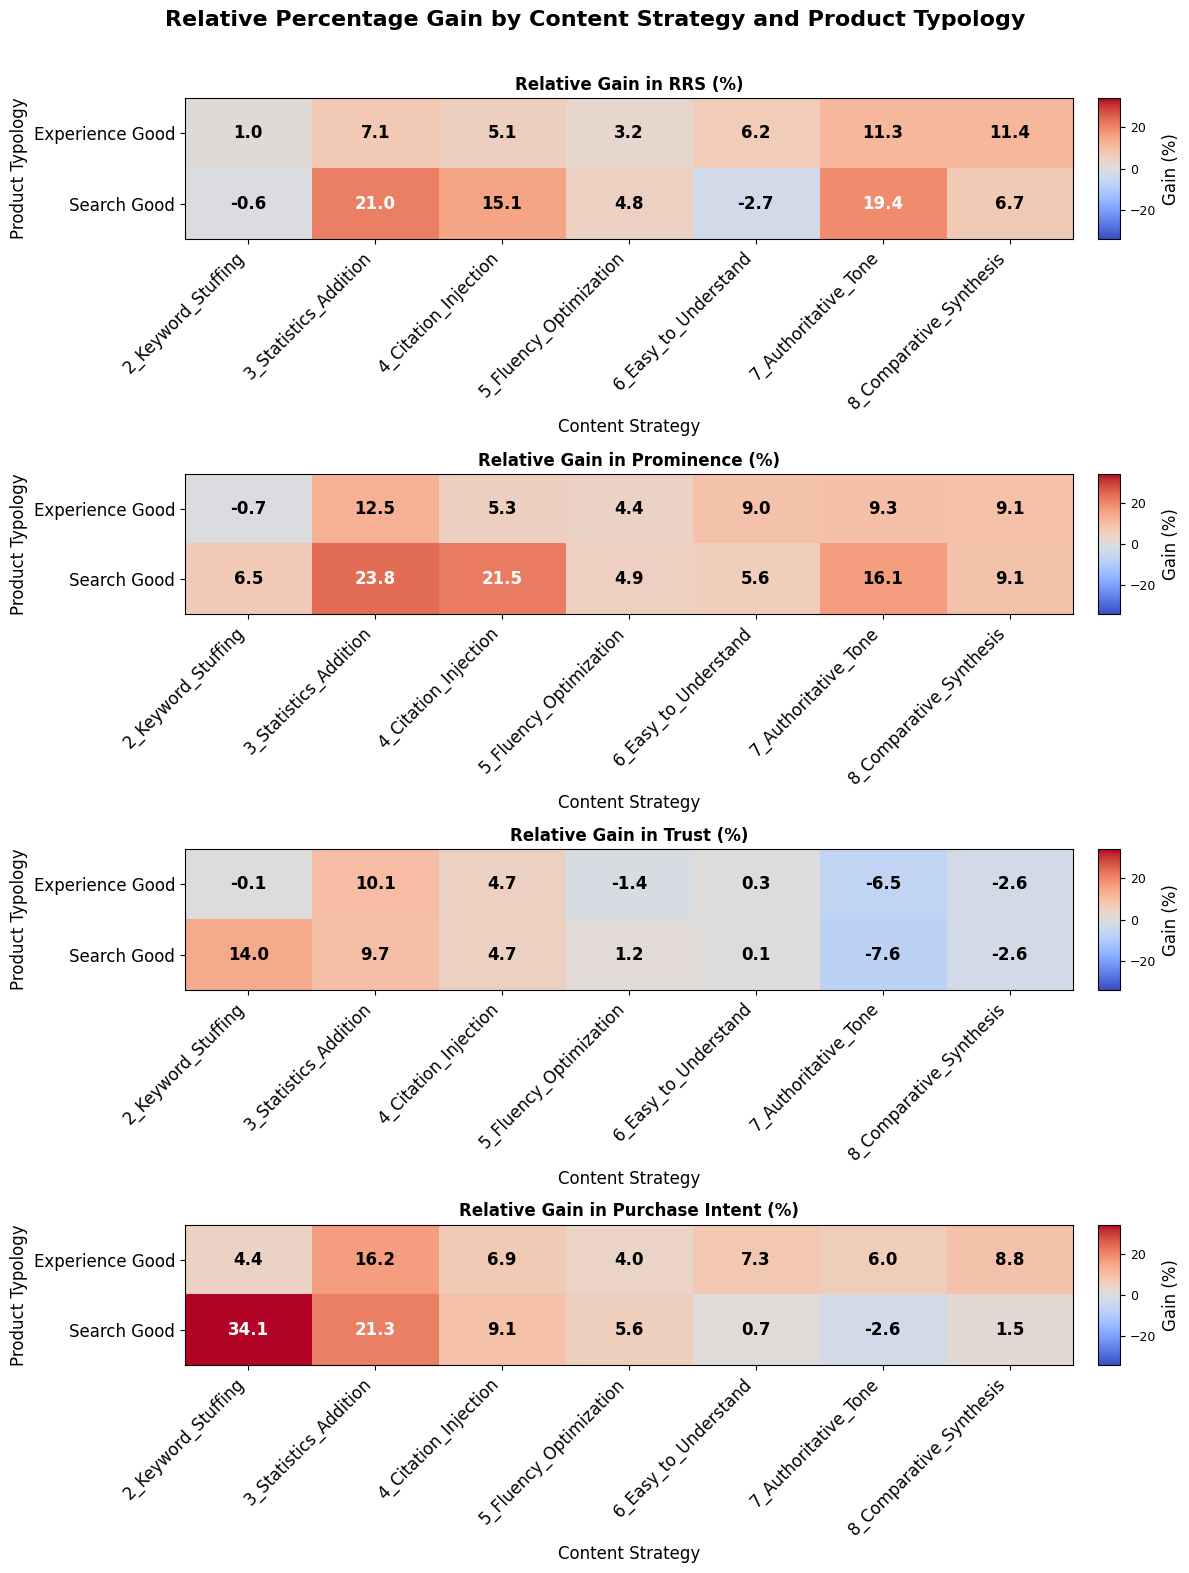

In [18]:
all_values = np.concatenate([
    matrix.values.flatten()
    for matrix in heatmap_matrices.values()
])

all_values = all_values[~np.isnan(all_values)]

abs_max = max(abs(all_values.min()), abs(all_values.max()))
vmin, vmax = -abs_max, abs_max

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

for ax, dv in zip(axes, dv_cols):
    matrix = heatmap_matrices[dv]

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(dv_titles[dv], fontsize=12, fontweight="bold")

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))

    ax.set_xticklabels(matrix.columns, rotation=45, ha="right", fontsize=12)
    ax.set_yticklabels(matrix.index, fontsize=12)

    ax.set_xlabel("Content Strategy", fontsize=12)
    ax.set_ylabel("Product Typology", fontsize=12)

    # value labels
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            value = matrix.values[i, j]
            if not np.isnan(value):
                text_color = "white" if abs(value) > (vmax * 0.5) else "black"
                ax.text(
                    j, i,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color=text_color
                )

    # colorbar for each subplot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.25)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Gain (%)", fontsize=12)
    cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Relative Percentage Gain by Content Strategy and Product Typology",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig("relative_gain_heatmap_vertical_final.png", dpi=300, bbox_inches="tight")
plt.show()
